In [41]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random,matplotlib
import missingno as msno
import warnings
warnings.filterwarnings('ignore')
import nltk as nlp
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
%matplotlib inline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam


In [2]:
from google.colab import files
uploaded = files.upload()

Saving fake_job_postings.csv to fake_job_postings.csv


In [3]:

df = pd.read_csv("fake_job_postings.csv")
print(df.shape)
df.head()

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [6]:
df['fraudulent'].value_counts()


,count
fraudulent,
0,17014
1,866


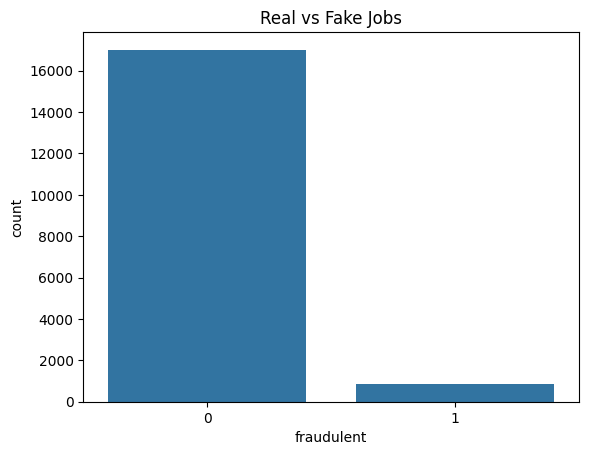

In [7]:
sns.countplot(x='fraudulent', data=df)
plt.title("Real vs Fake Jobs")
plt.show()

<Axes: >

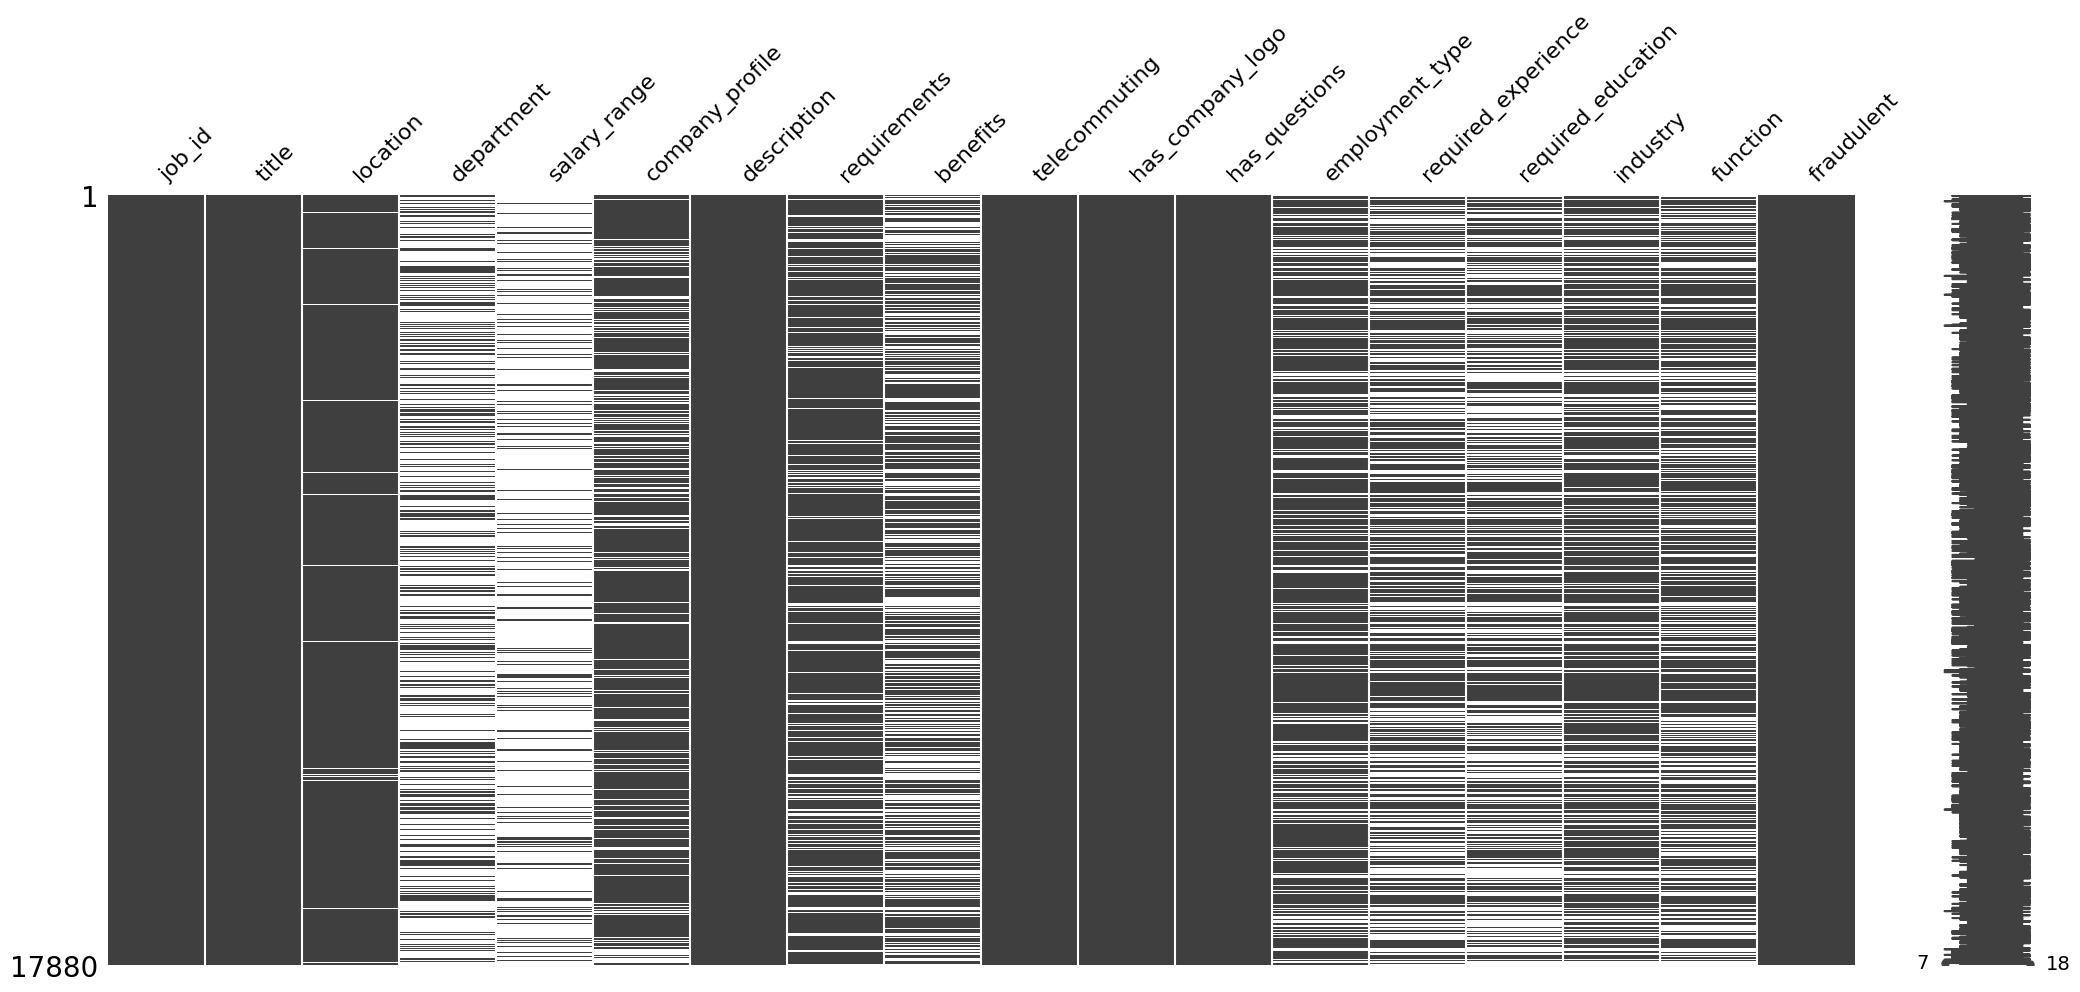

In [4]:
msno.matrix(df)

<Axes: >

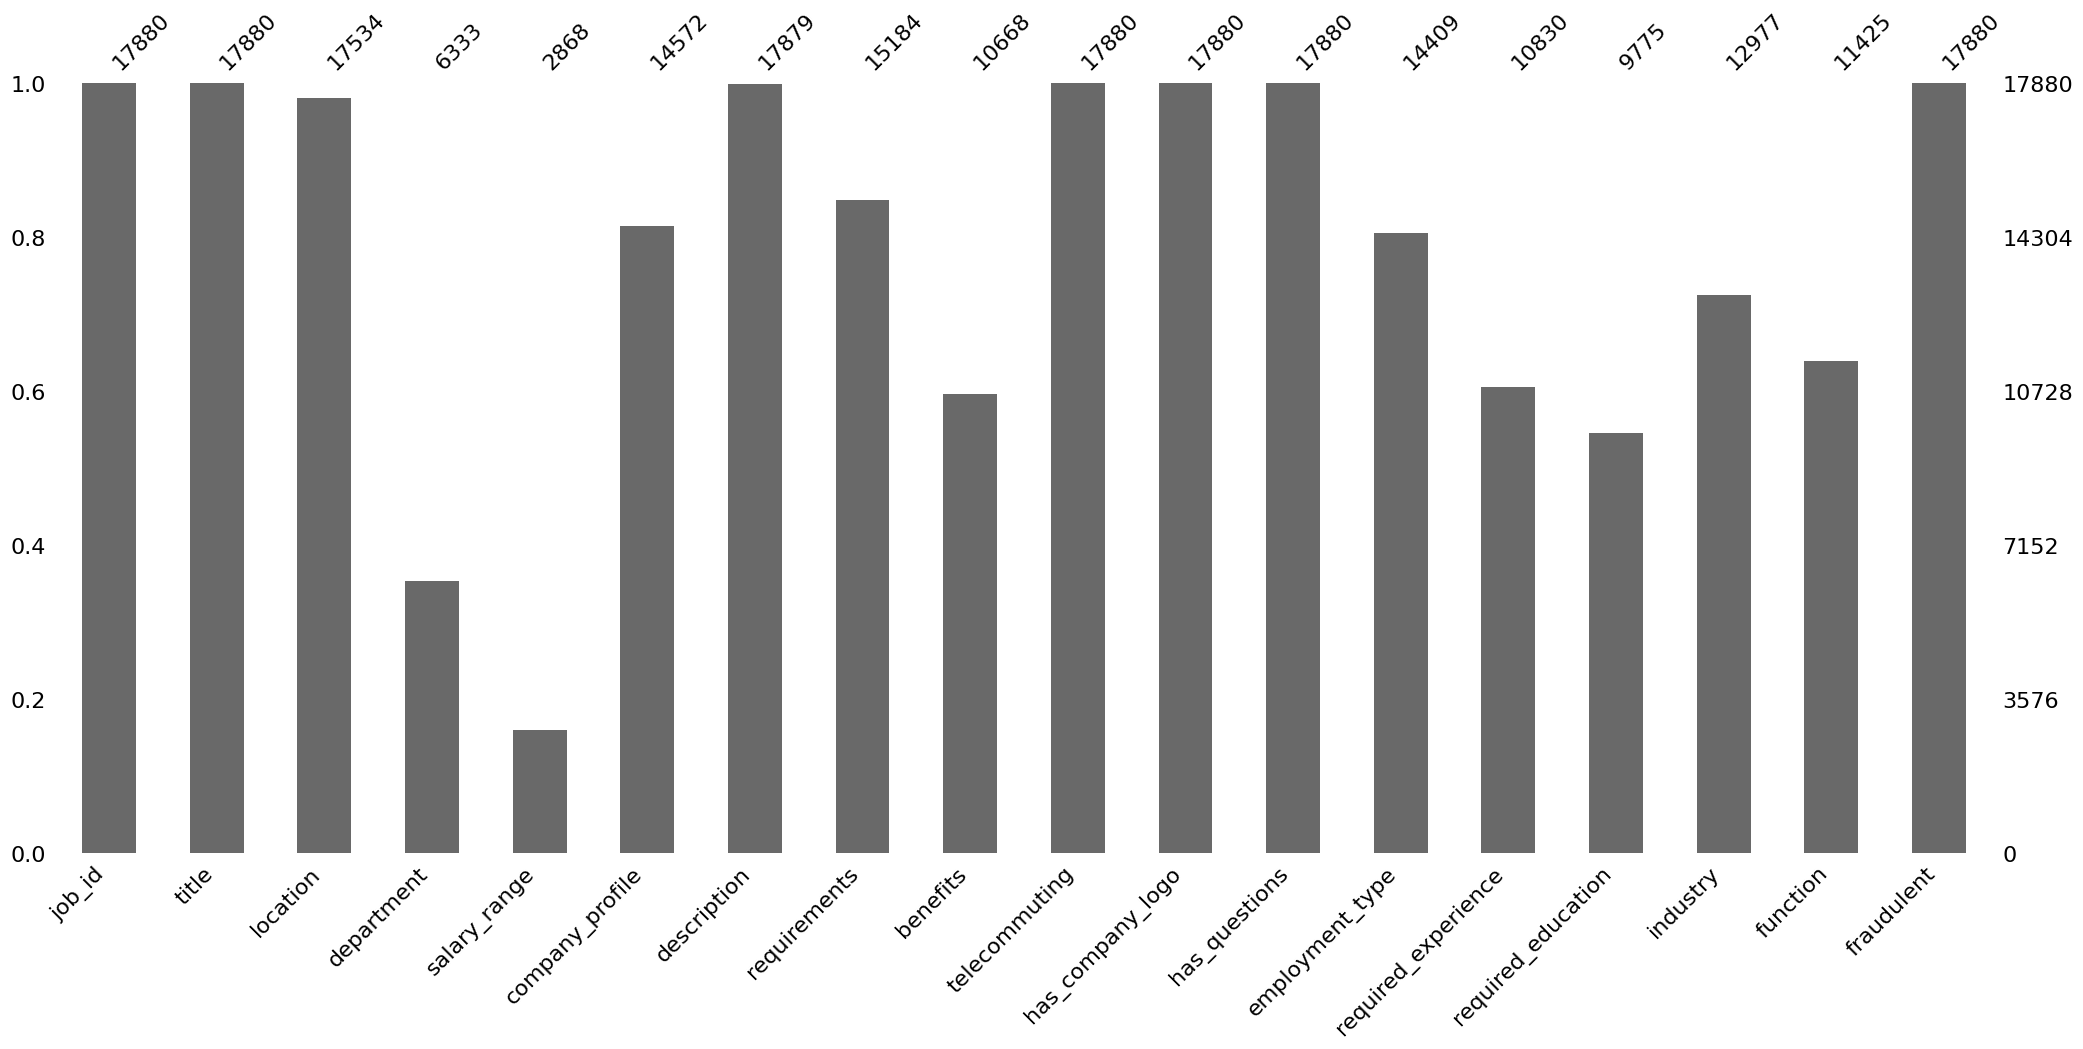

In [5]:
msno.bar(df)

There are 528001 words in the combination of all available job titles.


(np.float64(-0.5), np.float64(1599.5), np.float64(799.5), np.float64(-0.5))

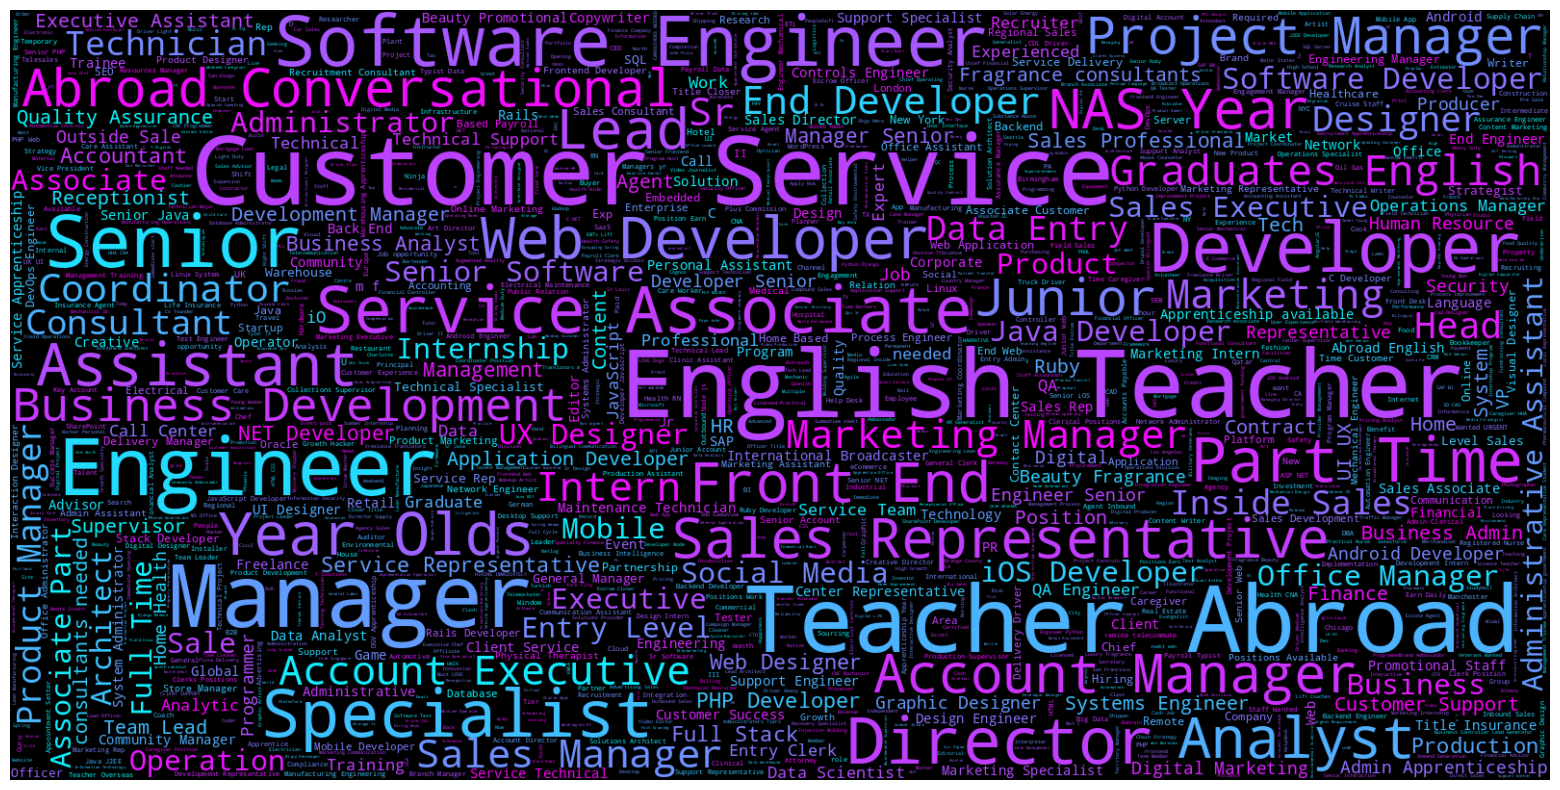

In [8]:
text = " ".join(title for title in df.title)
print ("There are {} words in the combination of all available job titles.".format(len(text)))
stopwords=set(STOPWORDS)
wordcloud = WordCloud(background_color="black",max_font_size=100, max_words=10000,width=1600, height=800,stopwords=stopwords,colormap=matplotlib.cm.cool).generate(text)
plt.figure(figsize=(20,10))
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")

In [9]:
# Dropping 'job_id' as it is irrelevant to fraudulent
df.drop('job_id', axis=1, inplace=True)
text_features = ['title', 'company_profile', 'description', 'requirements', 'benefits']
complex_features = ['location', 'salary_range']
bin_features = ['telecommuting', 'has_company_logo', 'has_questions']
cat_features = ['department', 'employment_type', 'required_experience',
                'required_education', 'industry', 'function']

In [10]:
df.isnull().sum()

,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0
has_company_logo,0


In [11]:
for feature_name in text_features[1:]:
    df[feature_name].fillna('Unspecified', inplace=True)

In [12]:
location = df['location'].copy()
#splitting location
location_splitted = list(location.str.split(', ').values)
for loc_ind, loc in enumerate(location_splitted):
    if loc is np.nan:
        location_splitted[loc_ind] = ['Unpecified'] * 3
    else:
        for el_ind, el in enumerate(loc):
            if el == '':
                loc[el_ind] = 'Unpecified'

location_splitted = list(map(lambda loc: list(loc), location_splitted))
for loc_ind, loc in enumerate(location_splitted):
    if len(loc) > 3:
        location_splitted[loc_ind] = loc[:2] + [', '.join(loc[2:])]
    if len(loc) < 3:
        location_splitted[loc_ind] += ['Unpecified'] * 2

data_location = pd.DataFrame(location_splitted, columns=['country', 'state', 'city'])
cat_features += ['country', 'state', 'city']
df= pd.concat([df, data_location], axis=1)
df.drop('location', axis=1, inplace=True)
df.head()

,title,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,country,state,city
0,Marketing Intern,Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Unspecified,0,1,0,Other,Internship,NaN,NaN,Marketing,0,US,NY,New York
1,Customer Service - Cloud Video Production,Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,NZ,Unpecified,Auckland
2,Commissioning Machinery Assistant (CMA),NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Unspecified,0,1,0,NaN,NaN,NaN,NaN,NaN,0,US,IA,Wever
3,Account Executive - Washington DC,Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,US,DC,Washington
4,Bill Review Manager,NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,US,FL,Fort Worth


In [13]:
salary_range = df.salary_range.copy()
salary_range.fillna('0-0', inplace=True)
salary_range_sep = list(salary_range.str.split('-').values)
salary_range_sep[5538] = ['40000', '40000']
error_range_inds = []
for range_ind, s_range in enumerate(salary_range_sep):
    min_value, max_value = s_range
    if not min_value.isdigit() or not max_value.isdigit():
        error_range_inds += [range_ind]
for range_ind in error_range_inds:
    salary_range_sep[range_ind] = ['0', '0']
data_salary_range = pd.DataFrame(np.array(salary_range_sep, dtype='int64'),
                                 columns=['min_salary', 'max_salary'])

num_features = ['min_salary', 'max_salary']
df = pd.concat([df, data_salary_range], axis=1)
df.drop('salary_range', axis=1, inplace=True)
df.head()

,title,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,country,state,city,min_salary,max_salary
0,Marketing Intern,Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Unspecified,0,1,0,Other,Internship,NaN,NaN,Marketing,0,US,NY,New York,0,0
1,Customer Service - Cloud Video Production,Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,NZ,Unpecified,Auckland,0,0
2,Commissioning Machinery Assistant (CMA),NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Unspecified,0,1,0,NaN,NaN,NaN,NaN,NaN,0,US,IA,Wever,0,0
3,Account Executive - Washington DC,Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,US,DC,Washington,0,0
4,Bill Review Manager,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,US,FL,Fort Worth,0,0


In [14]:
df.fillna('Unspecified', inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   department           17880 non-null  object
 2   company_profile      17880 non-null  object
 3   description          17880 non-null  object
 4   requirements         17880 non-null  object
 5   benefits             17880 non-null  object
 6   telecommuting        17880 non-null  int64 
 7   has_company_logo     17880 non-null  int64 
 8   has_questions        17880 non-null  int64 
 9   employment_type      17880 non-null  object
 10  required_experience  17880 non-null  object
 11  required_education   17880 non-null  object
 12  industry             17880 non-null  object
 13  function             17880 non-null  object
 14  fraudulent           17880 non-null  int64 
 15  country              17880 non-null  object
 16  stat

In [16]:
def clean_text(data):
    description_list = []
    for description in data:
        description = re.sub("[^a-zA-Z]"," ",description)
        description = description.lower()
        description = nlp.word_tokenize(description)
        description = [word for word in description if not word in stopwords]
        lemma = nlp.WordNetLemmatizer()
        description = [lemma.lemmatize(word) for word in description ]
        description =" ".join(description)
        description_list.append(description)
    return description_list

In [39]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
df['description_cleaned']= clean_text(df.description)
df['company_profile_cleaned']=clean_text(df.company_profile)
df['requirements_cleaned']= clean_text(df.requirements)
df['benefits_cleaned']=clean_text(df.benefits)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [21]:
df['title_length']=df['title'].astype(str).str.split(' ').apply(len)
df['company_profile_length']=df['company_profile_cleaned'].astype(str).str.split(' ').apply(len)
df['benefits_length']=df['benefits_cleaned'].astype(str).str.split(' ').apply(len)
df['description_length']=df['description_cleaned'].astype(str).str.split(' ').apply(len)
df['requirements_length']=df['requirements_cleaned'].astype(str).str.split(' ').apply(len)

In [22]:
label=LabelEncoder()
df['employment_type']=label.fit_transform(df['employment_type'])
df['required_experience']=label.fit_transform(df['required_experience'])
df['required_education']=label.fit_transform(df['required_education'])
df['industry']=label.fit_transform(df['industry'])
df['function']=label.fit_transform(df['function'])
df['country']=label.fit_transform(df['country'])
df['state']=label.fit_transform(df['state'])
df['city']=label.fit_transform(df['city'])

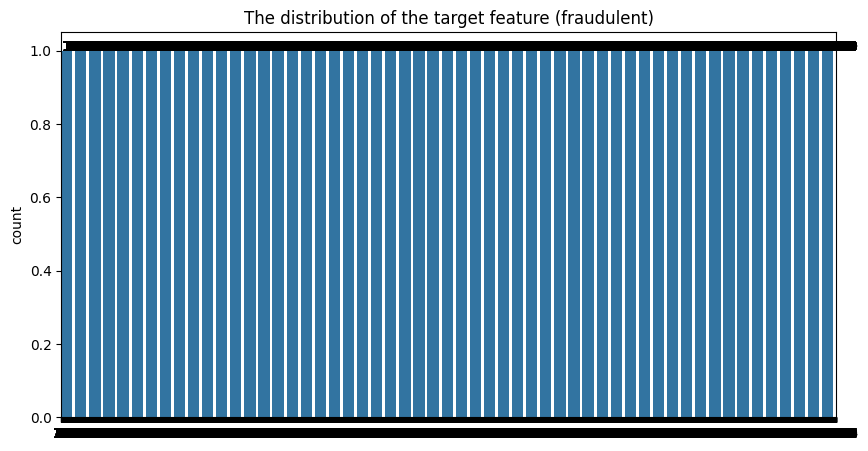

In [24]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(df.fraudulent)
plt.title('The distribution of the target feature (fraudulent)')
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x()+0.33, p.get_height()))

In [25]:
data_1f = df[df.fraudulent == 1]
original_data = df.copy()
df = pd.concat([df] + [data_1f] * 7, axis=0)

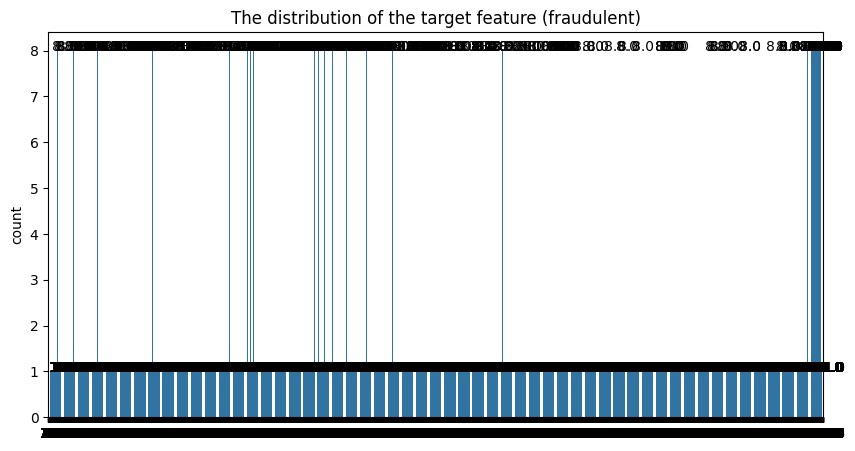

In [26]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(df.fraudulent)
plt.title('The distribution of the target feature (fraudulent)')
for p in ax.patches:
    ax.annotate(p.get_height(), (p.get_x()+0.33, p.get_height()))
plt.show()

In [29]:
X=check=df.drop(['title','department','company_profile','description','requirements','benefits','description_cleaned','company_profile_cleaned','requirements_cleaned','benefits_cleaned','fraudulent'],axis=1)
y=df.fraudulent

In [30]:
X

,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,country,state,city,min_salary,max_salary,title_length,company_profile_length,benefits_length,description_length,requirements_length
0,0,1,0,2,4,9,123,22,85,227,1457,0,0,2,92,1,84,76
1,0,1,0,1,6,9,75,7,60,293,188,0,0,6,157,111,208,133
2,0,1,0,5,7,9,123,36,85,155,2213,0,0,4,81,1,31,126
3,0,1,0,1,5,1,22,31,85,104,2164,0,0,5,58,77,230,124
4,0,1,1,1,5,1,51,16,85,130,786,0,0,3,169,3,132,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17827,0,0,0,3,7,9,123,36,85,83,1204,0,0,5,1,1,52,1
17828,0,0,1,5,7,9,123,36,5,221,2026,0,0,2,1,29,24,55
17829,0,0,0,5,7,9,123,36,65,203,2161,0,0,2,1,17,39,94
17830,0,0,0,1,7,9,4,0,85,227,1457,0,0,3,1,18,33,23


In [31]:
y

,fraudulent
0,0
1,0
2,0
3,0
4,0
...,...
17827,1
17828,1
17829,1
17830,1


In [32]:
scaler=MinMaxScaler()
X=scaler.fit_transform(X)

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
def roc_plotter(model_object,model_name):
        model_object.fit(X_train, y_train)
        y_pred=model_object.predict(X_test)
        ns_probs = [0 for _ in range(len(y_test))]

        # predict probabilities
        model_probs = model_object.predict_proba(X_test)[:, 1]

        # calculate scores
        ns_auc = roc_auc_score(y_test, ns_probs)
        model_auc = roc_auc_score(y_test, model_probs)

        fig = plt.figure(figsize=(12,5))

        # calculate roc curves
        ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
        lr_fpr, lr_tpr, _ = roc_curve(y_test, model_probs)
        # plot the roc curve for the model
        plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
        plt.plot(lr_fpr, lr_tpr, marker='.', label=model_name)

# axis labels
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        # show the legend
        plt.legend()
        # show the plot
        score= accuracy_score(y_test, y_pred)
        txt1='ROC AUC = {}'.format(round(model_auc,2))
        txt2='Accuracy = {}%'.format(round(score*100,2))

        plt.text(0.3,0.2,model_name,fontsize=25, fontweight='bold',color='red')
        plt.text(0.3,0.1,txt1,bbox={'facecolor': 'orange','pad': 10},fontsize=15)
        plt.text(0.5,0.1,txt2,bbox={'facecolor': 'red', 'pad': 10},fontsize=15,color='white')
        plt.tight_layout()

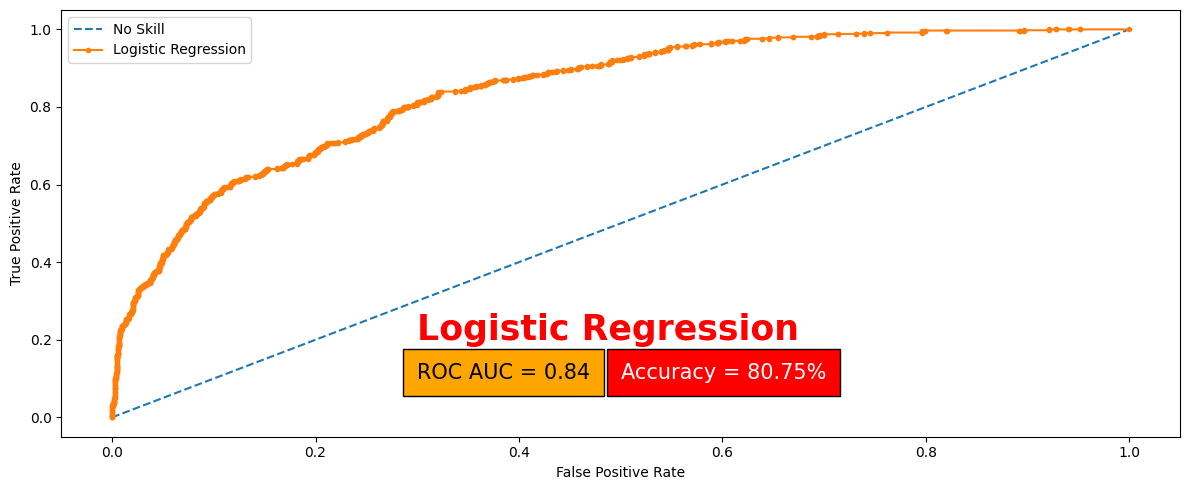

In [50]:
lrmodel=LogisticRegression()
roc_plotter(lrmodel,'Logistic Regression')

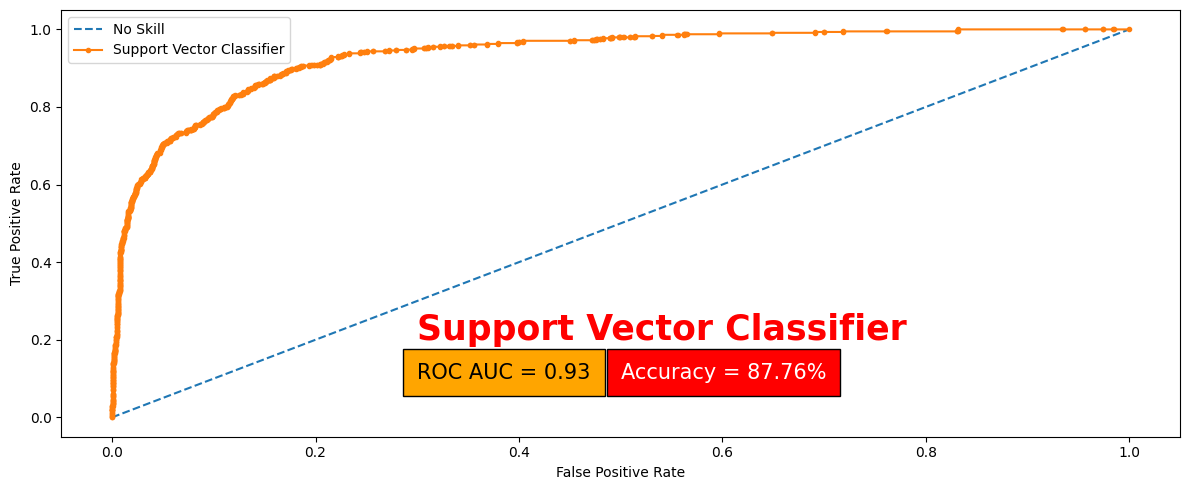

In [35]:
svmmodel=SVC(probability=True)
roc_plotter(svmmodel,'Support Vector Classifier')

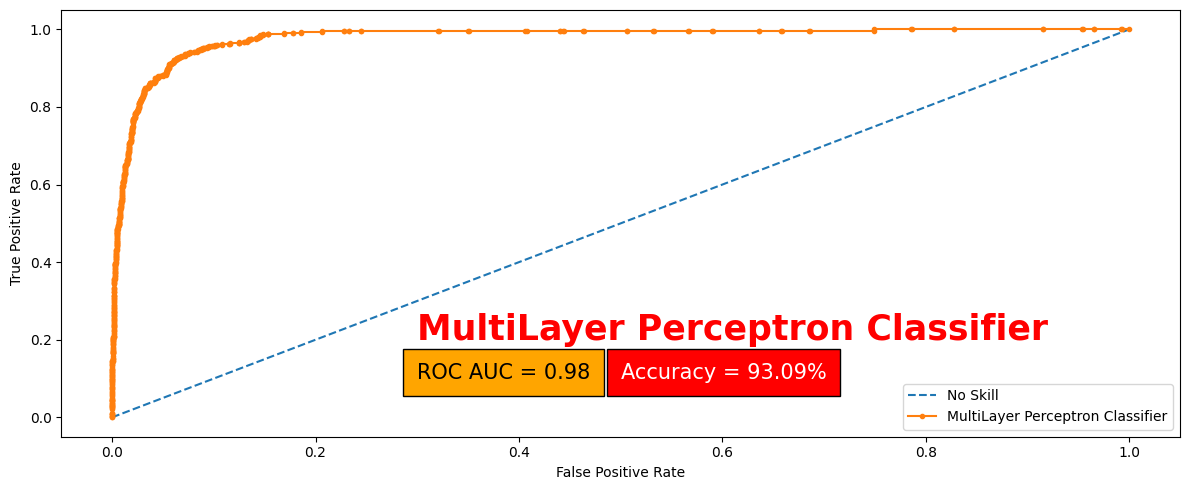

In [51]:
nnmodel=MLPClassifier()
roc_plotter(nnmodel,'MultiLayer Perceptron Classifier')

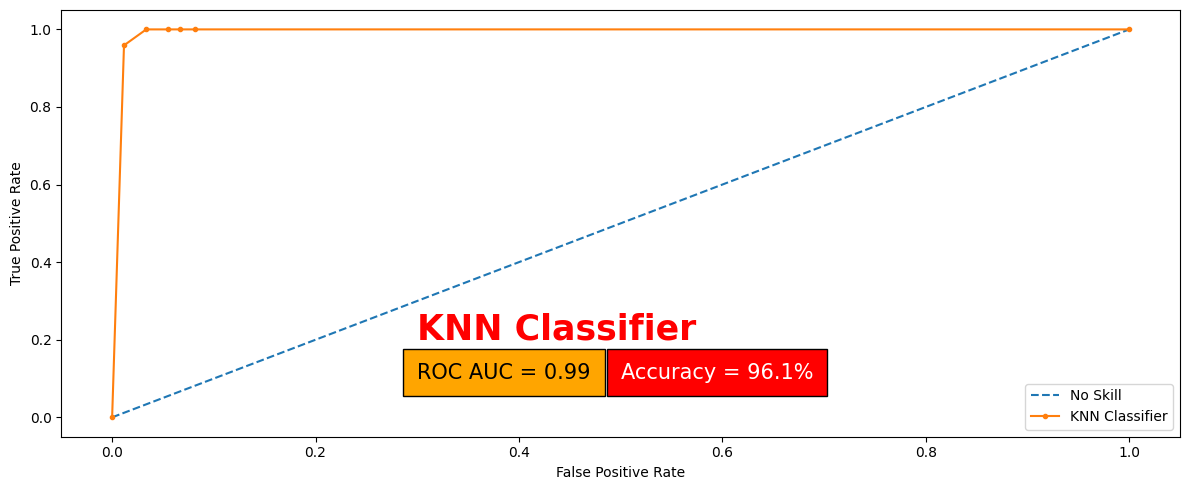

In [52]:
knnmodel=KNeighborsClassifier()
roc_plotter(knnmodel,'KNN Classifier')

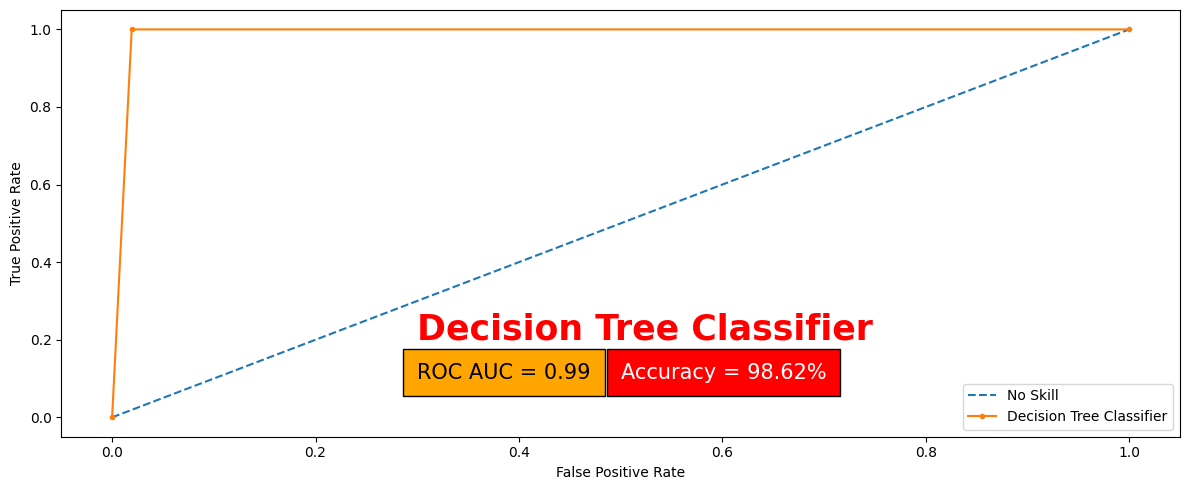

In [53]:
dtmodel=DecisionTreeClassifier()
roc_plotter(dtmodel,'Decision Tree Classifier')

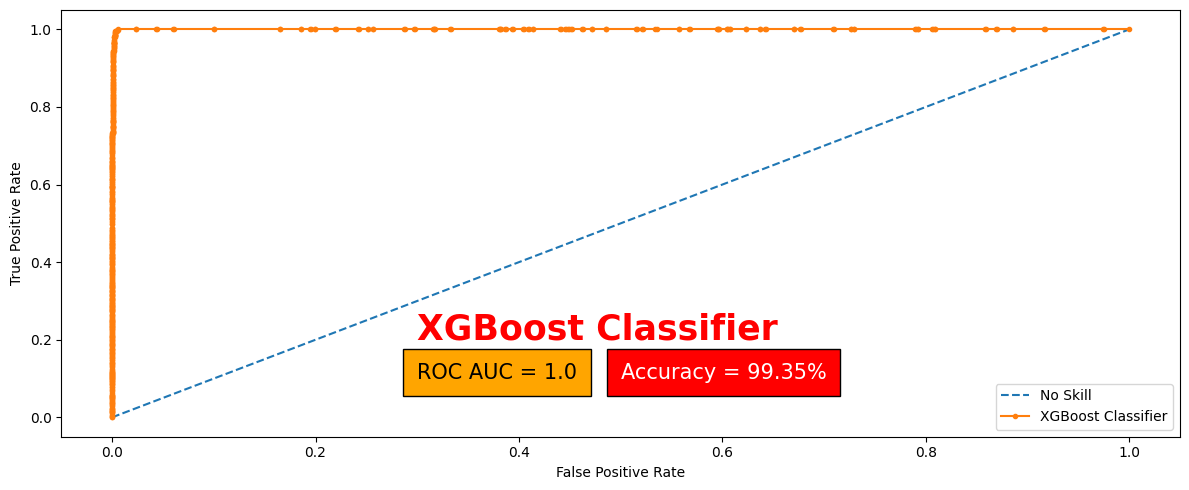

In [36]:
xgb = XGBClassifier()
roc_plotter(xgb,'XGBoost Classifier')

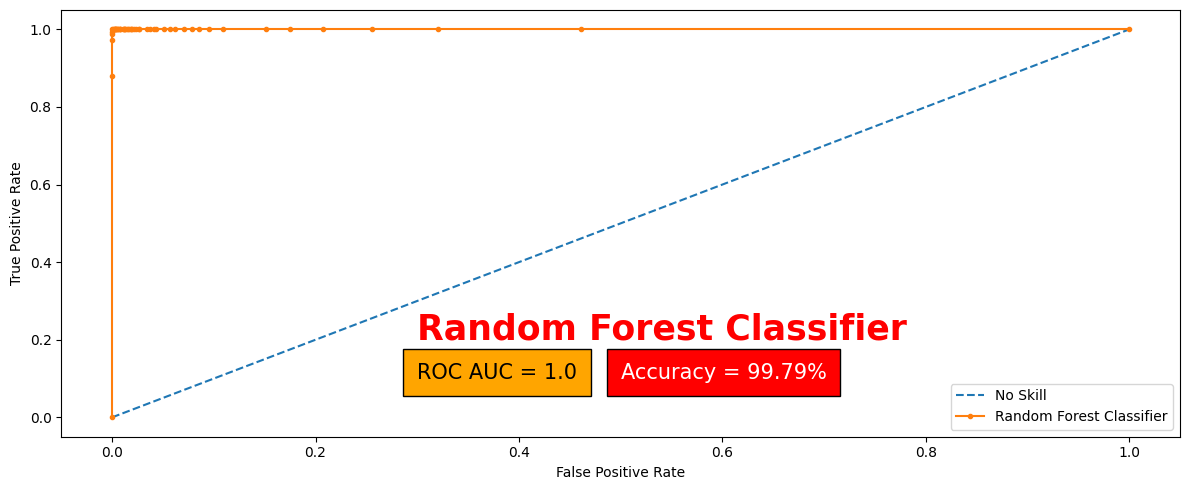

In [37]:
rfmodel=RandomForestClassifier()
roc_plotter(rfmodel,'Random Forest Classifier')

In [42]:
# Using cleaned description
texts = df['description_cleaned'].astype(str)
labels = df['fraudulent']

# Tokenization
max_words = 20000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

# Padding sequences
max_len = 200
X_lstm = pad_sequences(sequences, maxlen=max_len)

y_lstm = labels.values


In [43]:
from sklearn.model_selection import train_test_split

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42
)


In [44]:
model = Sequential()

model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

model.add(Bidirectional(LSTM(64, return_sequences=False)))

model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 72s 286ms/step - accuracy: 0.8262 - loss: 0.3896 - val_accuracy: 0.9794 - val_loss: 0.0617
Epoch 2/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 85s 302ms/step - accuracy: 0.9900 - loss: 0.0344 - val_accuracy: 0.9903 - val_loss: 0.0356
Epoch 3/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 70s 290ms/step - accuracy: 0.9968 - loss: 0.0134 - val_accuracy: 0.9906 - val_loss: 0.0336
Epoch 4/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 82s 293ms/step - accuracy: 0.9976 - loss: 0.0076 - val_accuracy: 0.9854 - val_loss: 0.0581
Epoch 5/5
240/240 ━━━━━━━━━━━━━━━━━━━━ 67s 280ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.9880 - val_loss: 0.0336


In [46]:
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm)
print("Bi-LSTM Accuracy: {:.2f}%".format(accuracy*100))


150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9901 - loss: 0.0287
Bi-LSTM Accuracy: 99.00%


150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step


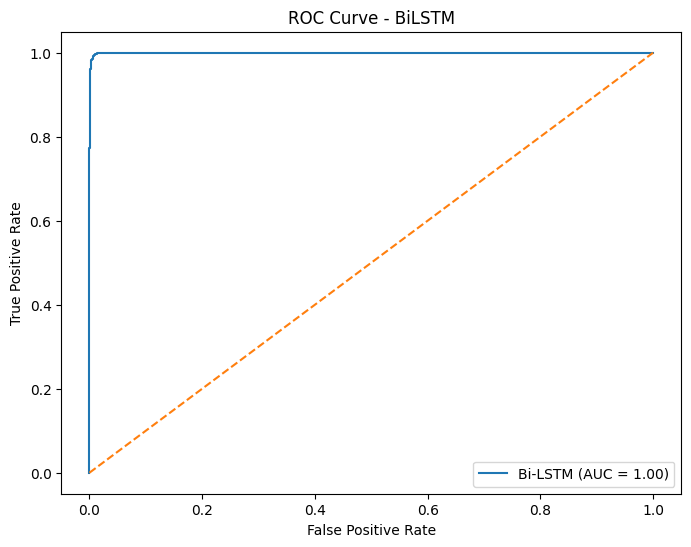

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_probs = model.predict(X_test_lstm)
y_pred_probs = y_pred_probs.ravel()

fpr, tpr, _ = roc_curve(y_test_lstm, y_pred_probs)
auc_score = roc_auc_score(y_test_lstm, y_pred_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Bi-LSTM (AUC = {:.2f})".format(auc_score))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BiLSTM")
plt.legend()
plt.show()


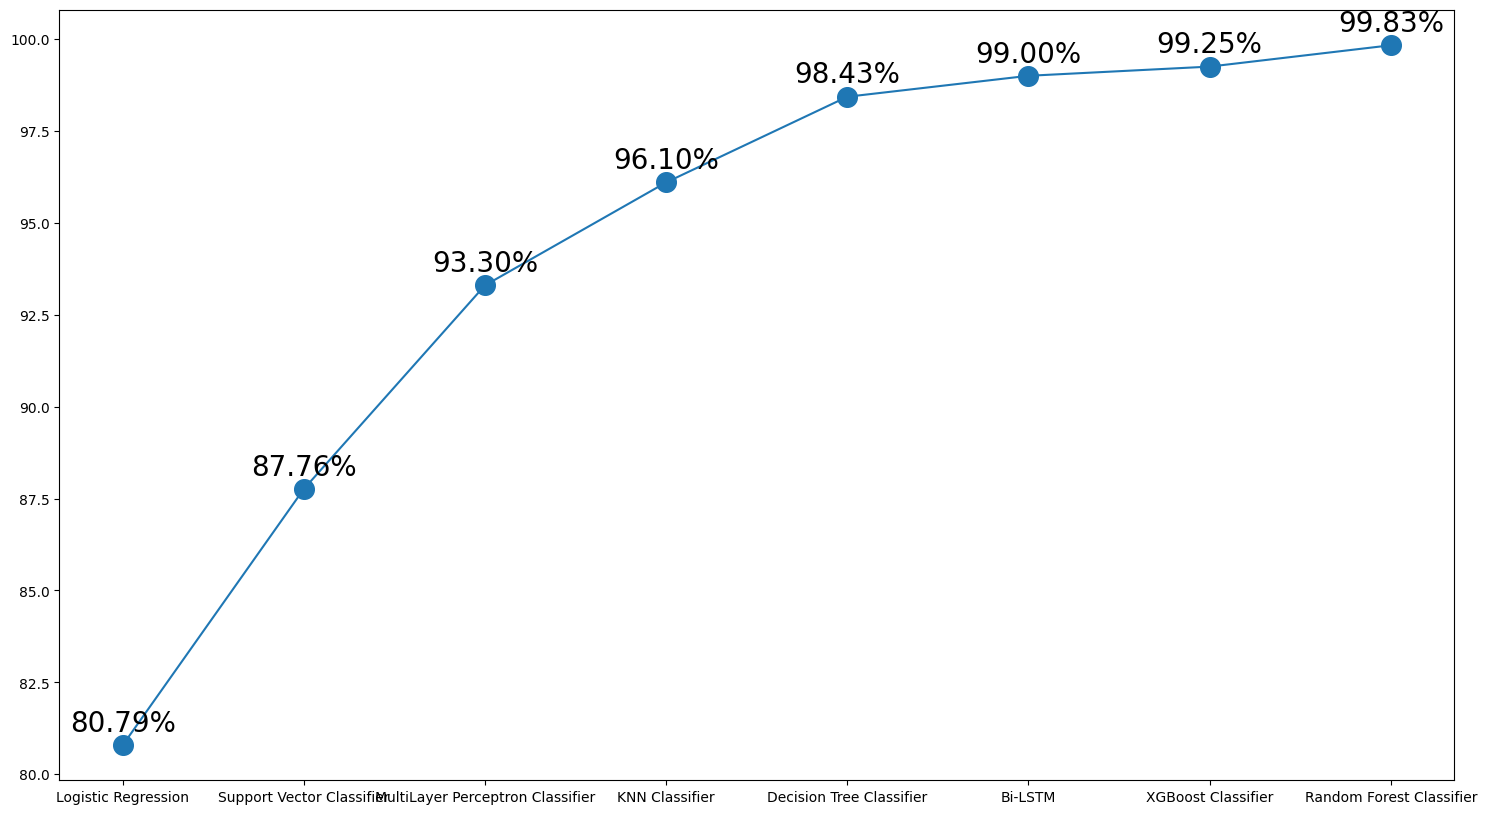

In [56]:
models=['Logistic Regression','Support Vector Classifier','MultiLayer Perceptron Classifier','KNN Classifier','Decision Tree Classifier','Bi-LSTM','XGBoost Classifier','Random Forest Classifier']
accuracies=[80.79,87.76,93.3,96.1,98.43,99.00,99.25,99.83]
plt.figure(figsize=(18,10))
plt.scatter(x=models, y=accuracies,s=200)
plt.plot(models,accuracies)
for x,y in zip(models,accuracies):
    label = "{:.2f}%".format(y)
    plt.annotate(label, (x,y), textcoords="offset points", xytext=(0,10), ha='center',fontsize=20)
